In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import *
from utils.data import *
# from metrics.graph import compare_dags
from utils.results import *
from utils.plotting import *

In [ ]:
# JPMF Data




In [17]:
from collections import defaultdict
import ast
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout
# from networkx.drawing.nx_pydot import graphviz_layout





def metadata_to_node_kind(metadata) -> dict:
    """
    Build {node: set(kinds)} from metadata with columns:
      - "Combs": list/tuple or string repr of it. Last entry is child, preceding are parents.
      - "Type": kind label (e.g., "SRV", "Pairwise", ...)
    """
    node_kind = defaultdict(set)
    if metadata is None:
        return node_kind

    for _, row in metadata.iterrows():
        comb = row["Combs"]
        if isinstance(comb, str):
            comb = ast.literal_eval(comb)

        if not isinstance(comb, (list, tuple)) or len(comb) < 2:
            raise ValueError(f"Invalid comb: {comb}")

        kind = str(row["Type"])
        *parents, child = comb

        # In your metadata viz you attach kind to the child node
        node_kind[int(child)].add(kind)

    return node_kind


def visualize_graph(
    dag: nx.DiGraph,
    # title="Causal Network Visualization",
    figsize=(10, 8),
    ax=None,
    metadata=None,
    # optional: if you want external labels dict like your first function
    labels=None,
    # optional: color by metadata types (SRV/Pairwise), else keep degree-based colors
    color_by_metadata=False,
):
    if dag is None or dag.number_of_edges() == 0:
        fig, ax2 = (ax.figure, ax) if ax is not None else plt.subplots(figsize=(6, 4))
        # ax2.set_title(title)
        ax2.text(0.5, 0.5, "No edges to display.", ha="center", va="center")
        ax2.axis("off")
        return fig, ax2

    # --- NEW: build node_kind from metadata ---
    node_kind = metadata_to_node_kind(metadata)

    use_nodes = {u for u, _ in dag.edges} | {v for _, v in dag.edges}
    H = dag.subgraph(use_nodes).copy()

    pos = graphviz_layout(H, prog="dot")
    # pos = graphviz_layout(H, prog="neato") 

    have_labels_attr = hasattr(dag, "labels") and isinstance(getattr(dag, "labels"), dict)

    # --- NEW: labels that include metadata kinds ---
    node_labels = {}
    for n in H.nodes:
        lines = [str(n)]

        # 1) prefer explicit labels passed in (like your first function)
        if labels is not None and n in labels and str(labels[n]).strip() != "":
            lines.append(str(labels[n]))
        # 2) else fall back to dag.labels if present
        elif have_labels_attr and n in dag.labels and str(dag.labels[n]).strip() != "":
            lines.append(str(dag.labels[n]))

        # 3) append metadata node kinds (SRV/Pairwise/...)
        kinds = node_kind.get(int(n), set()) if isinstance(n, (int,)) else node_kind.get(n, set())
        if kinds:
            lines.append("/".join(sorted(kinds)))

        node_labels[n] = "\n".join(lines)

    def _is_undirected_edge(G: nx.DiGraph, u, v) -> bool:
        uv = G.has_edge(u, v)
        vu = G.has_edge(v, u)

        kind_uv = G.edges[u, v].get("kind") if uv else None
        kind_vu = G.edges[v, u].get("kind") if vu else None

        if kind_uv == "undirected" or kind_vu == "undirected":
            return True

        # Common CPDAG encoding: both directions present => undirected adjacency
        if uv and vu and kind_uv != "directed" and kind_vu != "directed":
            return True

        return False

    # Split edges
    undirected_pairs = set()
    directed_edges = []

    for u, v in H.edges():
        if _is_undirected_edge(H, u, v):
            a, b = sorted((u, v), key=lambda x: str(x))
            undirected_pairs.add((a, b))
        else:
            directed_edges.append((u, v))

    # Colors
    if color_by_metadata:
        node_colors = []
        for n in H.nodes:
            kinds = node_kind.get(int(n), set()) if isinstance(n, int) else node_kind.get(n, set())
            if "SRV" in kinds and "Pairwise" in kinds:
                node_colors.append("violet")
            elif "SRV" in kinds:
                node_colors.append("salmon")
            elif "Pairwise" in kinds:
                node_colors.append("skyblue")
            else:
                node_colors.append("lightgrey")

        
        
    else:
        # Degrees for coloring: ignore undirected adjacencies
        Hd = nx.DiGraph()
        Hd.add_nodes_from(H.nodes())
        Hd.add_edges_from(directed_edges)

        node_colors = []
        for n in H.nodes:
            indeg = Hd.in_degree(n)
            outdeg = Hd.out_degree(n)
            if indeg == 0 and outdeg > 0:
                node_colors.append("palegreen")
            elif indeg > 0 and outdeg == 0:
                node_colors.append("salmon")
            else:
                node_colors.append("skyblue")

    fig, ax2 = (ax.figure, ax) if ax is not None else plt.subplots(figsize=figsize)

    # Draw nodes + labels
    nx.draw_networkx_nodes(
        H, pos, ax=ax2,
        node_color=node_colors,
        node_size=2200,
        edgecolors="black",
        linewidths=1.5,
    )
    nx.draw_networkx_labels(H, pos, labels=node_labels, ax=ax2, font_size=10)

    # Draw undirected edges (no arrows)
    nx.draw_networkx_edges(
        H, pos, ax=ax2,
        edgelist=list(undirected_pairs),
        arrows=False,
        width=2,
    )

    # Draw directed edges (with arrows)
    nx.draw_networkx_edges(
        H, pos, ax=ax2,
        edgelist=directed_edges,
        arrows=True,
        node_size=2200,
        arrowstyle="-|>",
        arrowsize=10,
        width=2,
    )

    # ax2.set_title(title)
    ax2.axis("off")
    fig.tight_layout()
    return fig, ax2


### Binary Data

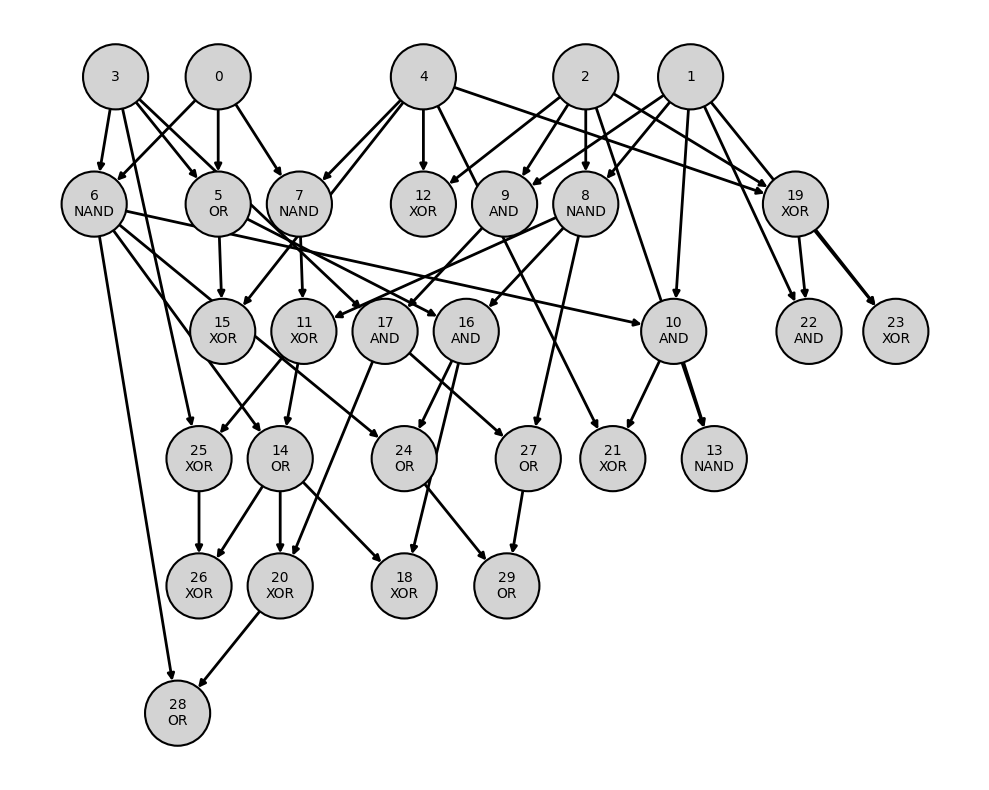

In [18]:
base_dir = "data/experiments/RQ1/binary_grid/"
df_num = 120
df = load_csv_with_attrs(base_dir + f"Data_Graph_{df_num}.csv")
metadata = pd.read_csv(base_dir + f"Metadata_Graph_{df_num}.csv")
true_cpdag = dag_to_cpdag(create_graph(metadata))

fig, ax = visualize_graph(true_cpdag, metadata=metadata, color_by_metadata=True)
# visualize_network_labels(metadata=metadata, title="True CPDAG - JPMF Grid")
fig.savefig(f"plots/Example_BinaryGrid.png", dpi=600)

### JPMF Data 

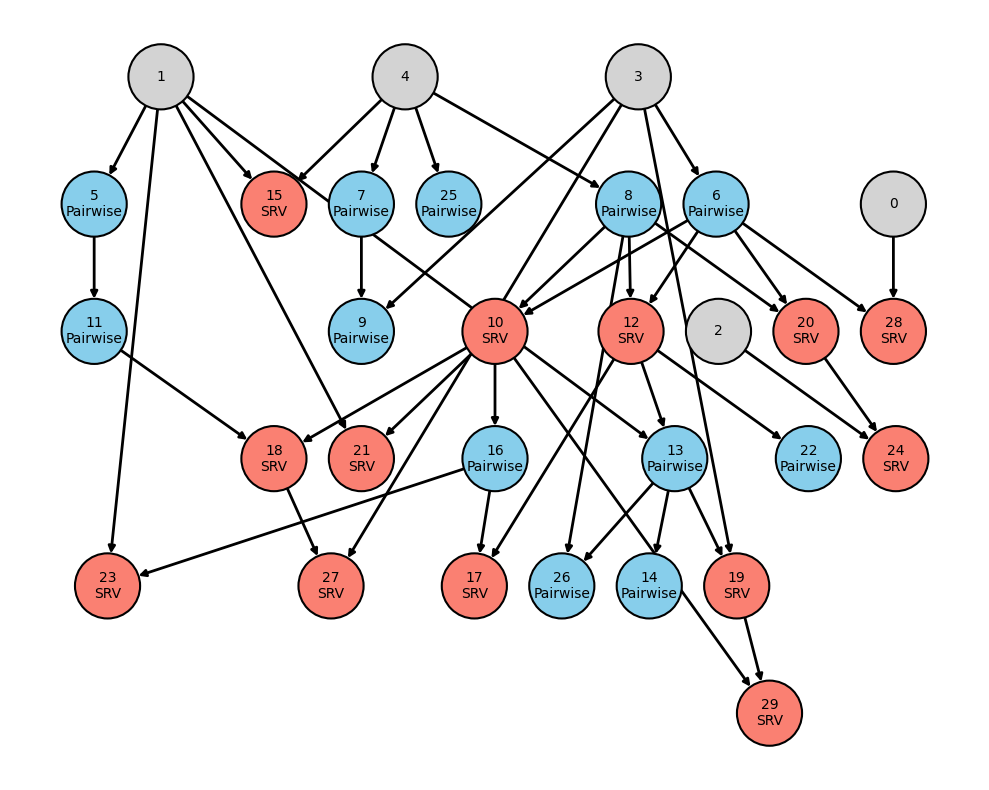

In [19]:
base_dir = "data/experiments/RQ1/jpmf_grid/"
df_num = 120
df = load_csv_with_attrs(base_dir + f"Data_Graph_{df_num}.csv")
metadata = pd.read_csv(base_dir + f"Metadata_Graph_{df_num}.csv")
true_dag = create_graph(metadata)
true_cpdag = dag_to_cpdag(true_dag)

fig, ax = visualize_graph(true_dag, metadata=metadata, color_by_metadata=True)
# visualize_network_labels(metadata=metadata, title="True CPDAG - JPMF Grid")
fig.savefig(f"plots/Example_JPMF.png", dpi=600)